In [ ]:
import pandas as pd

model_df = pd.read_csv(
    "../data/processed/leishmania_ml_dataset.csv"
)

model_df.head()

,Molecule ChEMBL ID,SMILES,pIC50,Molecular_Weight,AlogP,TPSA,HBA,HBD,RO5_Violations,Rotatable_Bonds,QED,Aromatic_Rings,Heavy_Atoms,NP_Likeness
0,CHEMBL1000,O=C(O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1,3.940555,388.90,3.15,53.01,4.0,1.0,0.0,8.0,0.70,2.0,27.0,-1.21
1,CHEMBL100210,CCCC[C@H]1C(=O)O[C@@H]2O[C@@]3(CC)CC[C@H]4[C@H...,4.443697,338.44,3.96,53.99,5.0,0.0,0.0,4.0,0.57,0.0,24.0,2.52
2,CHEMBL100740,C[C@@H]1CC[C@H]2[C@@H](C)C(=O)O[C@@H]3OC(C)(C)...,3.800519,284.35,2.64,53.99,5.0,0.0,0.0,0.0,0.51,0.0,20.0,2.66
3,CHEMBL104,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,5.242633,344.85,5.38,17.82,2.0,0.0,1.0,4.0,0.45,4.0,25.0,-0.58
4,CHEMBL106,OC(Cn1cncn1)(Cn1cncn1)c1ccc(F)cc1F,3.898138,306.28,0.74,81.65,7.0,1.0,0.0,5.0,0.75,3.0,22.0,-0.86


In [3]:
from rdkit import Chem

model_df["Mol"] = model_df["SMILES"].apply(
    Chem.MolFromSmiles
)

print(model_df["Mol"].notnull().sum())

5457


In [4]:
from rdkit.Chem import AllChem

model_df["FP"] = model_df["Mol"].apply(
    lambda mol:
    AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=1024
    )
)

[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerator
[01:04:56] DEPRECATION WARNING: please use MorganGenerat

In [5]:
subset = model_df.iloc[:500].copy()

In [6]:
from rdkit.DataStructs import TanimotoSimilarity

activity_cliffs = []

for i in range(len(subset)):

    fp1 = subset.iloc[i]["FP"]
    p1 = subset.iloc[i]["pIC50"]

    for j in range(i+1, len(subset)):

        fp2 = subset.iloc[j]["FP"]
        p2 = subset.iloc[j]["pIC50"]

        similarity = TanimotoSimilarity(
            fp1,
            fp2
        )

        delta_activity = abs(p1 - p2)

        if (
            similarity >= 0.80
            and
            delta_activity >= 2
        ):

            activity_cliffs.append([
                subset.iloc[i]["Molecule ChEMBL ID"],
                subset.iloc[j]["Molecule ChEMBL ID"],
                similarity,
                delta_activity
            ])

In [7]:
cliffs_df = pd.DataFrame(
    activity_cliffs,
    columns=[
        "Compound_1",
        "Compound_2",
        "Similarity",
        "Delta_pIC50"
    ]
)

cliffs_df.sort_values(
    "Delta_pIC50",
    ascending=False
).head(20)

,Compound_1,Compound_2,Similarity,Delta_pIC50


In [8]:
print(
    "Number of Activity Cliffs:",
    len(activity_cliffs)
)

Number of Activity Cliffs: 0


In [9]:
max_similarity = 0
max_delta = 0

for i in range(len(subset)):

    fp1 = subset.iloc[i]["FP"]
    p1 = subset.iloc[i]["pIC50"]

    for j in range(i + 1, len(subset)):

        fp2 = subset.iloc[j]["FP"]
        p2 = subset.iloc[j]["pIC50"]

        similarity = TanimotoSimilarity(fp1, fp2)
        delta = abs(p1 - p2)

        if similarity > max_similarity:
            max_similarity = similarity

        if delta > max_delta:
            max_delta = delta

print("Max Similarity:", round(max_similarity, 3))
print("Max Delta pIC50:", round(max_delta, 3))

Max Similarity: 1.0
Max Delta pIC50: 4.601


In [10]:
high_similarity_pairs = []

for i in range(len(subset)):

    fp1 = subset.iloc[i]["FP"]

    for j in range(i + 1, len(subset)):

        fp2 = subset.iloc[j]["FP"]

        similarity = TanimotoSimilarity(
            fp1,
            fp2
        )

        if similarity >= 0.80:

            delta = abs(
                subset.iloc[i]["pIC50"] -
                subset.iloc[j]["pIC50"]
            )

            high_similarity_pairs.append(
                [similarity, delta]
            )

print(
    "Number of pairs with similarity >= 0.80:",
    len(high_similarity_pairs)
)

Number of pairs with similarity >= 0.80: 363


In [11]:
pd.DataFrame(
    high_similarity_pairs,
    columns=[
        "Similarity",
        "Delta_pIC50"
    ]
).sort_values(
    "Delta_pIC50",
    ascending=False
).head(20)

,Similarity,Delta_pIC50
66,0.803279,1.653213
84,0.806452,1.651760
190,0.973684,1.619789
91,0.888889,1.406373
186,0.978261,1.266803
42,0.822222,1.241864
88,0.838710,1.130768
168,0.838710,1.128155
74,0.838710,1.096910
76,0.838710,1.094296


In [12]:
activity_cliffs = []

for i in range(len(subset)):

    fp1 = subset.iloc[i]["FP"]
    p1 = subset.iloc[i]["pIC50"]

    for j in range(i + 1, len(subset)):

        fp2 = subset.iloc[j]["FP"]
        p2 = subset.iloc[j]["pIC50"]

        similarity = TanimotoSimilarity(
            fp1,
            fp2
        )

        delta_activity = abs(
            p1 - p2
        )

        if (
            similarity >= 0.80
            and
            delta_activity >= 1.0
        ):

            activity_cliffs.append([
                subset.iloc[i]["Molecule ChEMBL ID"],
                subset.iloc[j]["Molecule ChEMBL ID"],
                similarity,
                delta_activity,
                p1,
                p2
            ])

In [13]:
cliffs_df = pd.DataFrame(
    activity_cliffs,
    columns=[
        "Compound_1",
        "Compound_2",
        "Similarity",
        "Delta_pIC50",
        "pIC50_1",
        "pIC50_2"
    ]
)

cliffs_df = cliffs_df.sort_values(
    "Delta_pIC50",
    ascending=False
)

print(
    "Number of Activity Cliffs:",
    len(cliffs_df)
)

cliffs_df.head(20)

Number of Activity Cliffs: 24


,Compound_1,Compound_2,Similarity,Delta_pIC50,pIC50_1,pIC50_2
3,CHEMBL1213505,CHEMBL1213587,0.803279,1.653213,4.346787,6.000000
8,CHEMBL1213587,CHEMBL1213589,0.806452,1.651760,6.000000,4.348240
18,CHEMBL165097,CHEMBL165562,0.973684,1.619789,4.000000,5.619789
11,CHEMBL1214455,CHEMBL1214461,0.888889,1.406373,5.886057,7.292430
17,CHEMBL164620,CHEMBL166026,0.978261,1.266803,5.266803,4.000000
0,CHEMBL1165207,CHEMBL1165357,0.822222,1.241864,3.076895,4.318759
10,CHEMBL1213626,CHEMBL134479,0.838710,1.130768,4.301030,5.431798
12,CHEMBL134479,CHEMBL135805,0.838710,1.128155,5.431798,4.303644
5,CHEMBL1213548,CHEMBL1213626,0.838710,1.096910,5.397940,4.301030
6,CHEMBL1213548,CHEMBL135805,0.838710,1.094296,5.397940,4.303644


## Activity Cliff Identification

Activity cliff analysis was performed using Morgan fingerprints (radius = 2, 1024 bits) and Tanimoto similarity. Compound pairs with structural similarity ≥ 0.80 and activity differences (ΔpIC50) ≥ 1.0 were considered activity cliffs. A total of 24 activity cliff pairs were identified among the first 500 compounds analyzed.

In [14]:
top_cliffs = cliffs_df.head(10)

top_cliffs

,Compound_1,Compound_2,Similarity,Delta_pIC50,pIC50_1,pIC50_2
3,CHEMBL1213505,CHEMBL1213587,0.803279,1.653213,4.346787,6.000000
8,CHEMBL1213587,CHEMBL1213589,0.806452,1.651760,6.000000,4.348240
18,CHEMBL165097,CHEMBL165562,0.973684,1.619789,4.000000,5.619789
11,CHEMBL1214455,CHEMBL1214461,0.888889,1.406373,5.886057,7.292430
17,CHEMBL164620,CHEMBL166026,0.978261,1.266803,5.266803,4.000000
0,CHEMBL1165207,CHEMBL1165357,0.822222,1.241864,3.076895,4.318759
10,CHEMBL1213626,CHEMBL134479,0.838710,1.130768,4.301030,5.431798
12,CHEMBL134479,CHEMBL135805,0.838710,1.128155,5.431798,4.303644
5,CHEMBL1213548,CHEMBL1213626,0.838710,1.096910,5.397940,4.301030
6,CHEMBL1213548,CHEMBL135805,0.838710,1.094296,5.397940,4.303644


In [15]:
cliff_compounds = pd.unique(
    pd.concat([
        top_cliffs["Compound_1"],
        top_cliffs["Compound_2"]
    ])
)

cliff_structures = subset[
    subset["Molecule ChEMBL ID"].isin(
        cliff_compounds
    )
][
    [
        "Molecule ChEMBL ID",
        "SMILES",
        "pIC50"
    ]
]

cliff_structures

,Molecule ChEMBL ID,SMILES,pIC50
78,CHEMBL1165207,COc1ccc(C(=O)c2cc3cccc(OC)c3oc2=S)cc1,3.076895
80,CHEMBL1165357,COc1cccc2cc(C(=O)c3ccc(Cl)cc3)c(=S)oc12,4.318759
129,CHEMBL1213505,C[C@@H]1CC[C@H]2[C@H](CCCc3ccccc3)C(=O)O[C@@H]...,4.346787
131,CHEMBL1213548,C[C@@H]1CC[C@H]2[C@@H](CCCc3cccc(F)c3)C(=O)O[C...,5.397940
134,CHEMBL1213587,CSc1ccc(CCC[C@H]2C(=O)O[C@@H]3O[C@@]4(C)CC[C@H...,6.000000
136,CHEMBL1213589,C[C@@H]1CC[C@H]2[C@@H](CCCc3ccc(O)cc3)C(=O)O[C...,4.348240
138,CHEMBL1213626,C[C@@H]1CC[C@H]2[C@@H](CCCc3cc(F)cc(F)c3)C(=O)...,4.301030
142,CHEMBL1214455,CC[C@@H](C(=O)C[C@@H](C)C1=C(O)C(=O)[C@@H]2C3=...,5.886057
148,CHEMBL1214461,CC[C@@H](C(=O)C[C@@H](C)C1=C(O)C(=O)[C@@H]2C3=...,7.292430
219,CHEMBL134479,C[C@@H]1CC[C@H]2[C@@H](CCCc3cccc(F)c3)C(=O)O[C...,5.431798


In [16]:
cliff_structures.to_csv(
    "../results/top_activity_cliff_compounds.csv",
    index=False
)

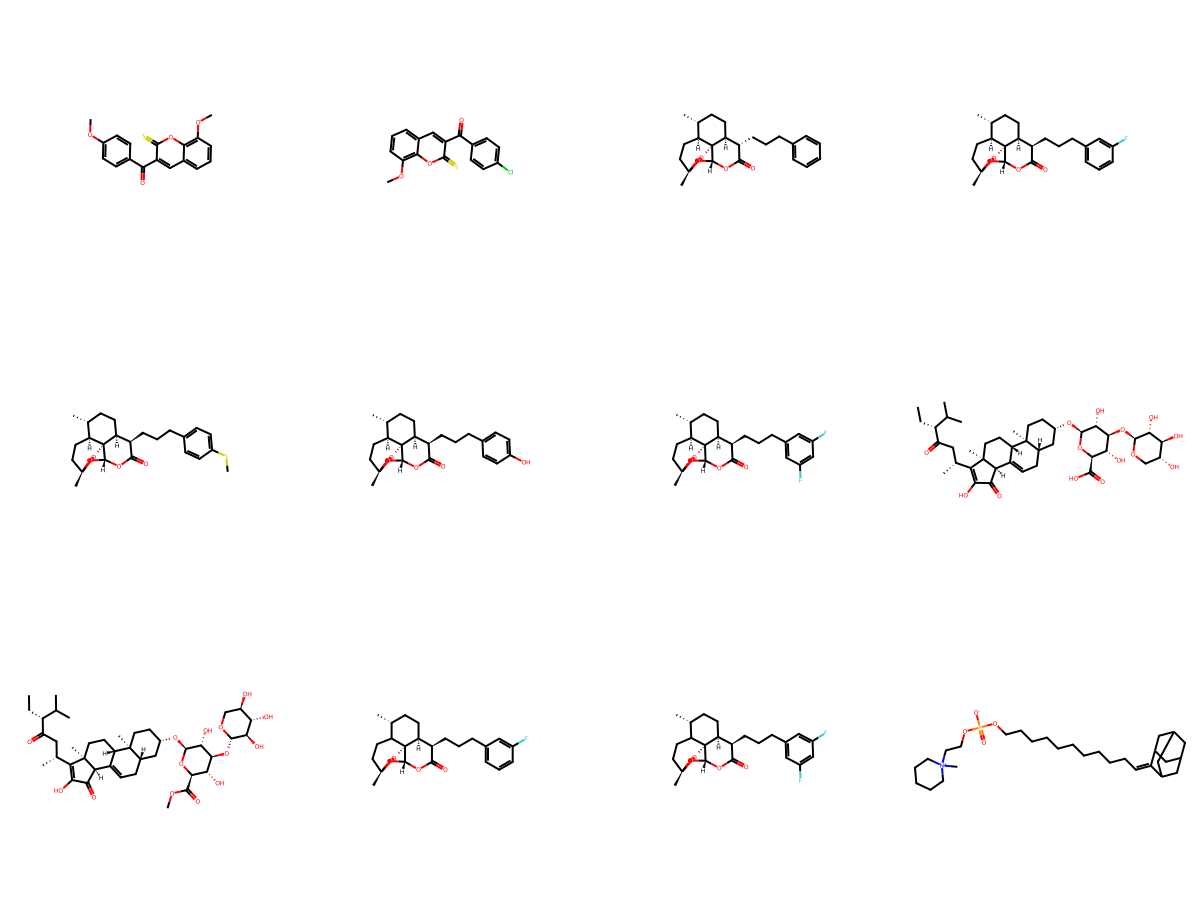

In [17]:
from rdkit.Chem import Draw

top_mols = [
    Chem.MolFromSmiles(smiles)
    for smiles in cliff_structures["SMILES"]
]

img = Draw.MolsToGridImage(
    top_mols[:12],
    molsPerRow=4,
    subImgSize=(300,300)
)

img

## Interpretation of Activity Cliffs

Several highly similar compound pairs exhibited substantial differences in biological activity despite sharing common structural scaffolds. The strongest activity cliffs displayed ΔpIC50 values greater than 1.0, corresponding to more than ten-fold differences in potency. These findings suggest that relatively small structural modifications can significantly influence anti-leishmanial activity and may provide valuable insights for lead optimization.

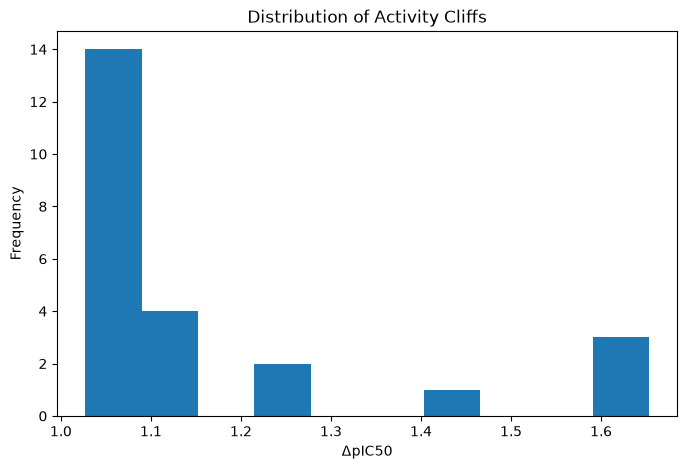

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    cliffs_df["Delta_pIC50"],
    bins=10
)

plt.xlabel("ΔpIC50")
plt.ylabel("Frequency")
plt.title("Distribution of Activity Cliffs")
plt.savefig(
    "../results/activity_cliff_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

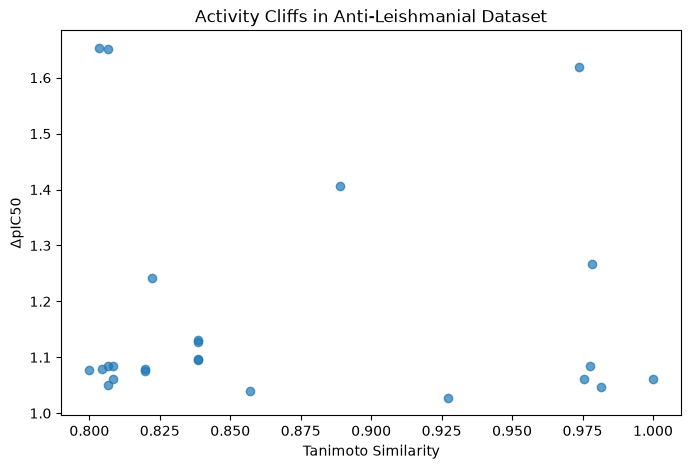

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(
    cliffs_df["Similarity"],
    cliffs_df["Delta_pIC50"],
    alpha=0.7
)

plt.xlabel("Tanimoto Similarity")
plt.ylabel("ΔpIC50")

plt.title(
    "Activity Cliffs in Anti-Leishmanial Dataset"
)
plt.savefig(
    "../results/activity_cliff_scatter.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [21]:
cliffs_df.head(20).to_csv(
    "../results/top_20_activity_cliffs.csv",
    index=False
)

In [22]:
cliffs_df.to_csv(
    "../results/activity_cliffs_full.csv",
    index=False
)